In [50]:
import pandas as pd

# Load datasets
df_breakup = pd.read_csv(r"C:\Users\Ahone\Desktop\Data analytics project\datasets\raw\reddit_breakup_dataset_cleaned.csv")
df_advice = pd.read_csv(r"C:\Users\Ahone\Desktop\Data analytics project\datasets\raw\relationship_advice.csv")

# Standardise columns
df_breakup_clean = df_breakup[['title', 'body', 'upvotes', 'comments_count', 'post_date']].copy()
df_breakup_clean.columns = ['title', 'body', 'score', 'comms_num', 'timestamp']
df_breakup_clean['source'] = 'breakups'

df_advice_clean = df_advice[['title', 'body', 'score', 'comms_num', 'timestamp']].copy()
df_advice_clean['source'] = 'relationship_advice'

# Combine
df = pd.concat([df_breakup_clean, df_advice_clean], ignore_index=True)

print(df.shape)
print(df.isnull().sum())
df.head()

(2833, 6)
title        0
body         0
score        0
comms_num    0
timestamp    0
source       0
dtype: int64


,title,body,score,comms_num,timestamp,source
0,"Been on both sides of a breakup now, here’s wh...",Two weeks ago I ended a nearly 2 year relation...,259,129,30/06/2025 00:55,breakups
1,I saw my ex with his new gf,I broke up with him on May 2nd. By June 6th he...,21,32,30/06/2025 14:21,breakups
2,Didn’t think losing someone who was already di...,"We hadn’t really been ""us"" for a while. The te...",22,5,30/06/2025 13:40,breakups
3,7 year relationship gone in an instant.,I moved citys to live together and had our own...,54,9,30/06/2025 08:39,breakups
4,When they come back it’s never worth it.,Post says it all. He came back after a few mon...,111,25,30/06/2025 03:54,breakups


In [51]:
# step 2 : text cleaning

import re

def clean_text(text):
    text = str(text).lower()                          # lowercase
    text = re.sub(r'http\S+', '', text)               # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)              # remove punctuation & numbers
    text = re.sub(r'\s+', ' ', text).strip()          # remove extra whitespace
    return text

df['title_clean'] = df['title'].apply(clean_text)
df['body_clean'] = df['body'].apply(clean_text)

# Quick check
df[['title', 'title_clean', 'body_clean']].head(3)

,title,title_clean,body_clean
0,"Been on both sides of a breakup now, here’s wh...",been on both sides of a breakup now heres what...,two weeks ago i ended a nearly year relationsh...
1,I saw my ex with his new gf,i saw my ex with his new gf,i broke up with him on may nd by june th he wa...
2,Didn’t think losing someone who was already di...,didnt think losing someone who was already dis...,we hadnt really been us for a while the texts ...


In [52]:
# feature engineering 

# Post length (word count of body)
df['body_length'] = df['body_clean'].apply(lambda x: len(x.split()))

# Publish hour
df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed', dayfirst=True)
df['publish_hour'] = df['timestamp'].dt.hour

# Engagement label (binary: 1 = high, 0 = low)
median_score = df['score'].median()
df['high_engagement'] = (df['score'] > median_score).astype(int)

print("Median score:", median_score)
print(df[['body_length', 'publish_hour', 'high_engagement']].describe())

Median score: 1.0
       body_length  publish_hour  high_engagement
count  2833.000000   2833.000000      2833.000000
mean    225.872926      9.560537         0.316978
std     256.511795      6.740443         0.465381
min       0.000000      0.000000         0.000000
25%      60.000000      5.000000         0.000000
50%     147.000000      6.000000         0.000000
75%     298.000000     16.000000         1.000000
max    2940.000000     23.000000         1.000000


In [53]:
# Check empty bodies
empty_bodies = df[df['body_length'] == 0]
print(f"Posts with empty body: {len(empty_bodies)}")
print(empty_bodies[['title', 'body', 'source']].head(5))

Posts with empty body: 8
                                                  title  \
663   “midnight snack” by Kiran + Nivi is so good so...   
936   “Breakups suck, but silence is worse. Just nee...   
1615                                             grouth   
1669  Does intrusion of technology is making our rel...   
1993                                            Comment   

                                                   body               source  
663    https://youtu.be/yPG2ix4d2vA?si=9-gZyw8OULqJ6eBb             breakups  
936                                                   >             breakups  
1615  [https://youtu.be/Gl9RlTwD10Y](https://youtu.b...  relationship_advice  
1669  [https://kinchit.substack.com/p/artifically-or...  relationship_advice  
1993                                                  🤣  relationship_advice  


In [54]:
df = df[df['body_length'] > 0].reset_index(drop=True)
print(df.shape)

(2825, 11)


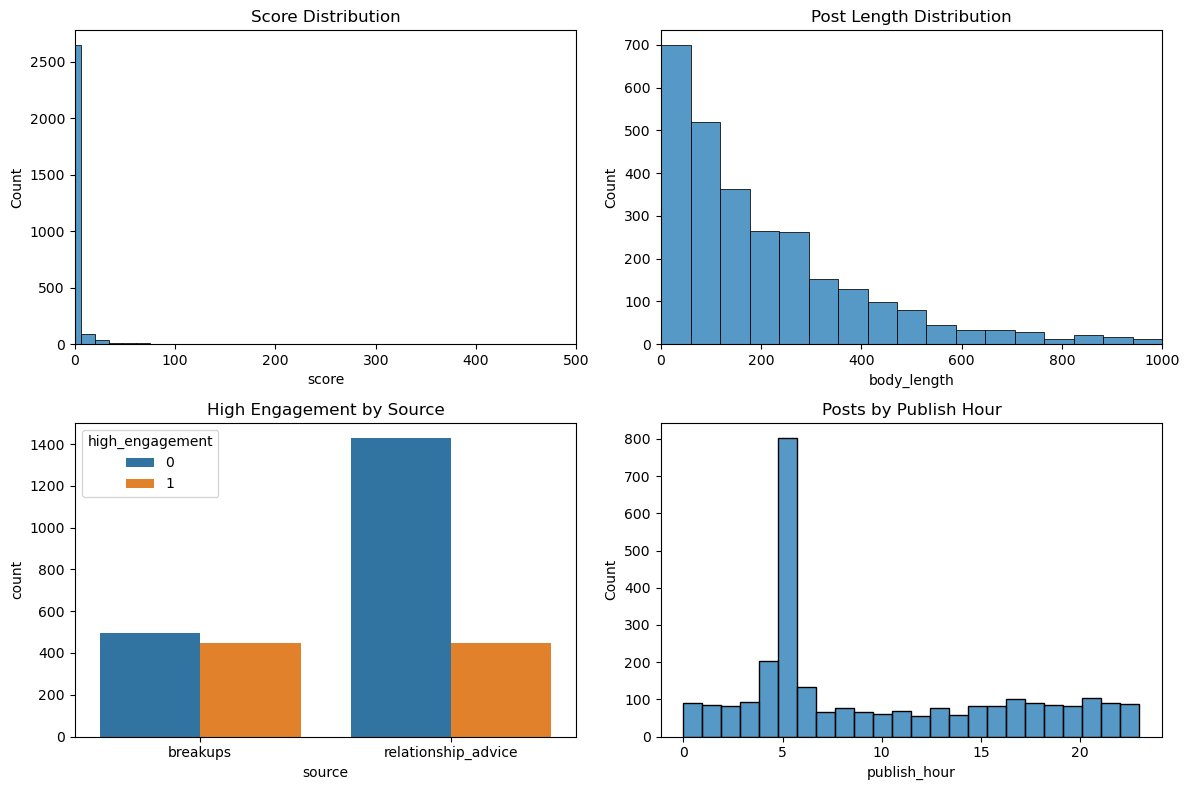

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Score distribution
sns.histplot(df['score'], bins=50, ax=axes[0,0])
axes[0,0].set_title('Score Distribution')
axes[0,0].set_xlim(0, 500)

# Body length distribution
sns.histplot(df['body_length'], bins=50, ax=axes[0,1])
axes[0,1].set_title('Post Length Distribution')
axes[0,1].set_xlim(0, 1000)

# Engagement split by source
sns.countplot(data=df, x='source', hue='high_engagement', ax=axes[1,0])
axes[1,0].set_title('High Engagement by Source')

# Posts by hour
sns.histplot(df['publish_hour'], bins=24, ax=axes[1,1])
axes[1,1].set_title('Posts by Publish Hour')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150)
plt.show()

In [56]:
# Step 3: Sentiment Scoring with VADER

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

# Score both title and body
df['title_sentiment'] = df['title_clean'].apply(lambda x: analyzer.polarity_scores(x)['compound'])
df['body_sentiment'] = df['body_clean'].apply(lambda x: analyzer.polarity_scores(x)['compound'])

# Categorise sentiment into negative / neutral / positive
def sentiment_label(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['body_sentiment_label'] = df['body_sentiment'].apply(sentiment_label)

print(df['body_sentiment_label'].value_counts())
print(df[['title_sentiment', 'body_sentiment']].describe())

body_sentiment_label
positive    1613
negative    1087
neutral      125
Name: count, dtype: int64
       title_sentiment  body_sentiment
count      2825.000000     2825.000000
mean         -0.018731        0.166286
std           0.307454        0.759715
min          -0.937100       -0.999700
25%          -0.040200       -0.648600
50%           0.000000        0.371000
75%           0.000000        0.914100
max           0.969500        0.999800


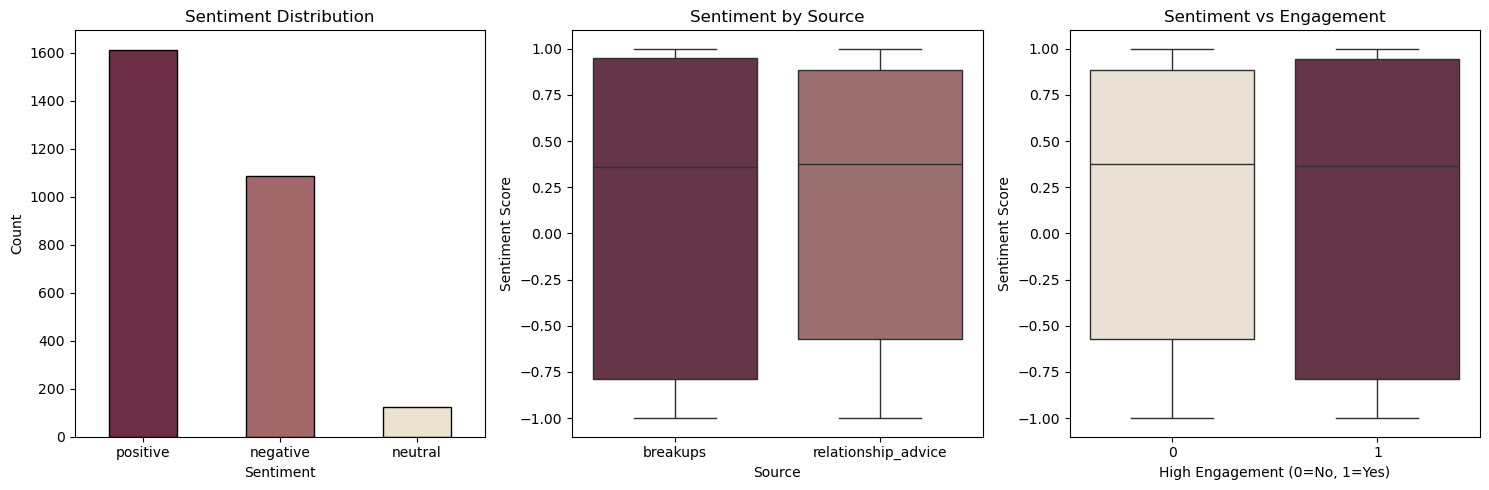

In [57]:
# Step 4: Sentiment Visualizations

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Sentiment label distribution
df['body_sentiment_label'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#6D2E46', '#A26769', '#ECE2D0'], edgecolor='black'
)
axes[0].set_title('Sentiment Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Body sentiment by source
sns.boxplot(data=df, x='source', y='body_sentiment', ax=axes[1],
            hue='source', palette=['#6D2E46', '#A26769'], legend=False)
axes[1].set_title('Sentiment by Source')
axes[1].set_xlabel('Source')
axes[1].set_ylabel('Sentiment Score')

# Sentiment vs engagement
sns.boxplot(data=df, x='high_engagement', y='body_sentiment', ax=axes[2],
            hue='high_engagement', palette=['#ECE2D0', '#6D2E46'], legend=False)
axes[2].set_title('Sentiment vs Engagement')
axes[2].set_xlabel('High Engagement (0=No, 1=Yes)')
axes[2].set_ylabel('Sentiment Score')

plt.tight_layout()
plt.savefig('sentiment_analysis.png', dpi=150)
plt.show()

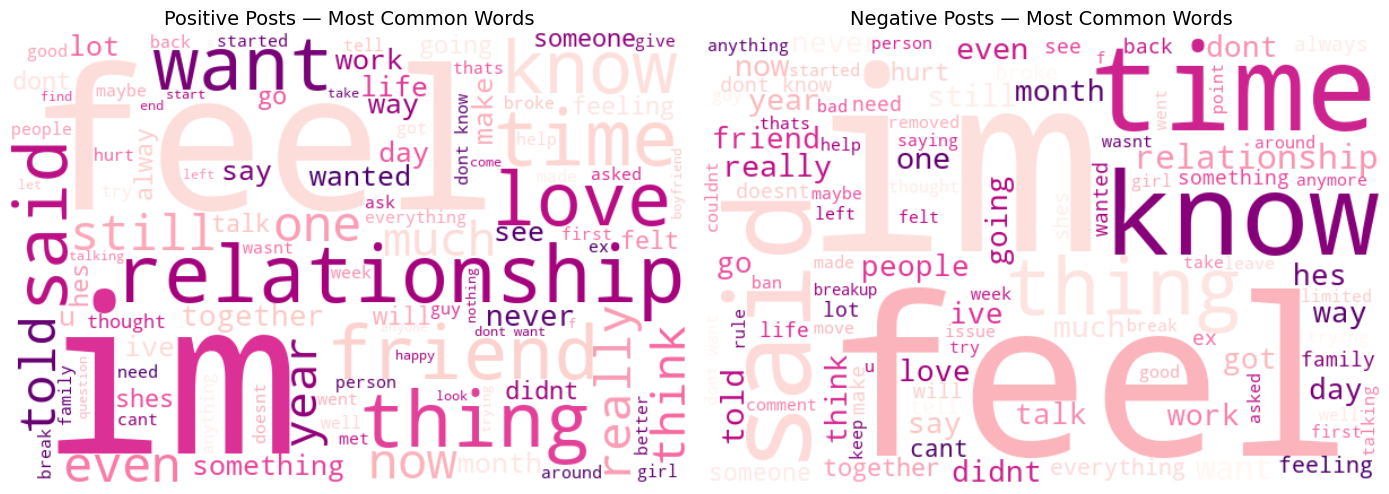

In [58]:
# Step 5: Word Clouds by Sentiment

from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, label, color in zip(axes, ['positive', 'negative'], ['#6D2E46', '#A26769']):
    text = ' '.join(df[df['body_sentiment_label'] == label]['body_clean'])
    wc = WordCloud(width=600, height=400, background_color='white',
                   colormap='RdPu', max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{label.capitalize()} Posts — Most Common Words', fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150)
plt.show()

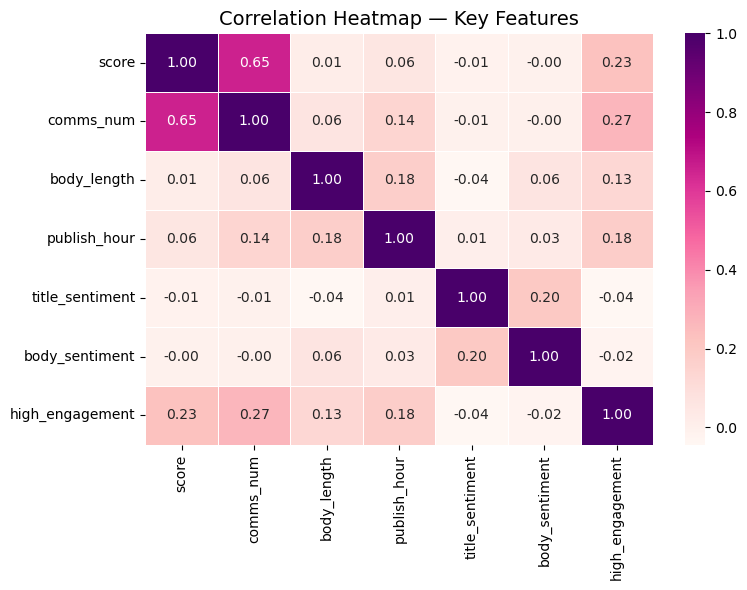

In [59]:
# Step 6: Correlation Heatmap

fig, ax = plt.subplots(figsize=(8, 6))

corr_cols = ['score', 'comms_num', 'body_length', 'publish_hour', 
             'title_sentiment', 'body_sentiment', 'high_engagement']

corr_matrix = df[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdPu',
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap — Key Features', fontsize=14)

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

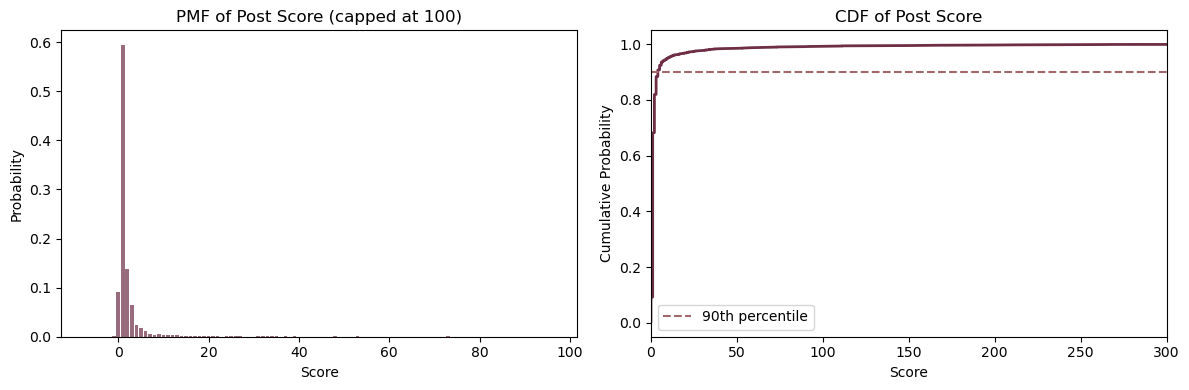

In [60]:
# Step 7: PMF and CDF of Score

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# PMF — cap at 100 for readability
score_capped = df[df['score'] <= 100]['score']
score_pmf = score_capped.value_counts(normalize=True).sort_index()
axes[0].bar(score_pmf.index, score_pmf.values, color='#6D2E46', alpha=0.7)
axes[0].set_title('PMF of Post Score (capped at 100)')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Probability')

# CDF
import numpy as np
sorted_scores = np.sort(df['score'].values)
cdf = np.arange(1, len(sorted_scores)+1) / len(sorted_scores)
axes[1].plot(sorted_scores, cdf, color='#6D2E46', linewidth=2)
axes[1].set_xlim(0, 300)
axes[1].set_title('CDF of Post Score')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Cumulative Probability')
axes[1].axhline(y=0.9, color='#A26769', linestyle='--', label='90th percentile')
axes[1].legend()

plt.tight_layout()
plt.savefig('pmf_cdf.png', dpi=150)
plt.show()

In [61]:
# Step 8: Model Preparation

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score, 
                             recall_score, confusion_matrix, classification_report)

# Feature set and target
features = ['body_length', 'publish_hour', 'title_sentiment', 
            'body_sentiment', 'comms_num']
X = df[features]
y = df['high_engagement']

# Train/test split — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Engagement split in test set:\n{y_test.value_counts()}")

Training set: (2260, 5)
Test set: (565, 5)
Engagement split in test set:
high_engagement
0    385
1    180
Name: count, dtype: int64


In [62]:
# Step 9: Train and Evaluate All Three Models

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
}

results = {}

for name, model in models.items():
    # Use scaled features for LR, unscaled for tree-based models
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred)
    }
    
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(classification_report(y_test, y_pred))

# Summary table
results_df = pd.DataFrame(results).T
print("\n--- Model Comparison Summary ---")
print(results_df.round(3))


  Logistic Regression
              precision    recall  f1-score   support

           0       0.72      0.94      0.82       385
           1       0.65      0.23      0.34       180

    accuracy                           0.72       565
   macro avg       0.69      0.59      0.58       565
weighted avg       0.70      0.72      0.67       565


  Decision Tree
              precision    recall  f1-score   support

           0       0.71      0.94      0.81       385
           1       0.60      0.19      0.29       180

    accuracy                           0.70       565
   macro avg       0.65      0.56      0.55       565
weighted avg       0.68      0.70      0.64       565


  Random Forest
              precision    recall  f1-score   support

           0       0.72      0.93      0.81       385
           1       0.61      0.24      0.35       180

    accuracy                           0.71       565
   macro avg       0.67      0.59      0.58       565
weighted avg     

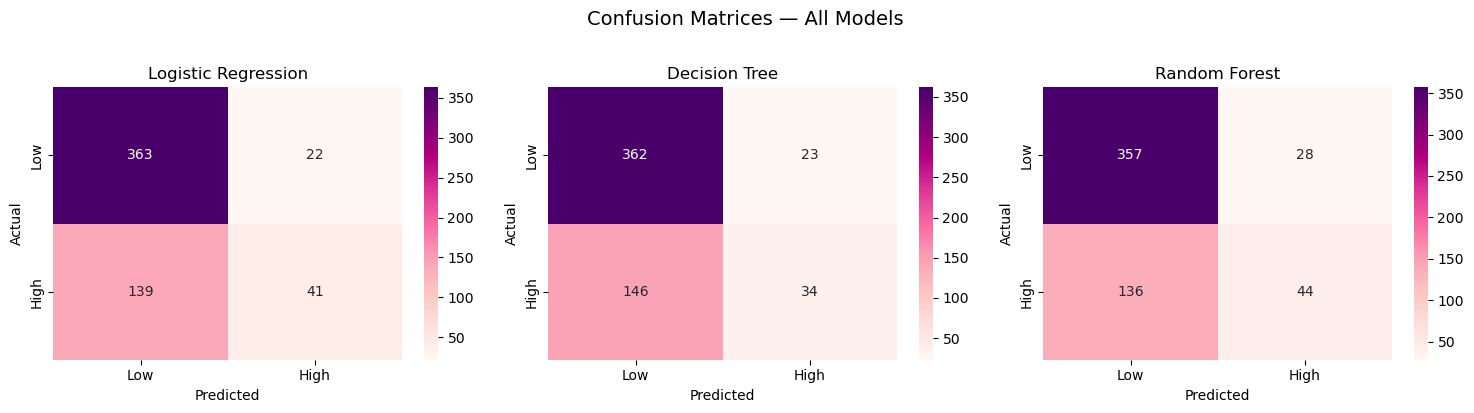

In [63]:
# Step 10: Confusion Matrices

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

model_list = [
    ('Logistic Regression', models['Logistic Regression'], X_test_scaled),
    ('Decision Tree', models['Decision Tree'], X_test),
    ('Random Forest', models['Random Forest'], X_test)
]

for ax, (name, model, X_input) in zip(axes, model_list):
    y_pred = model.predict(X_input)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', ax=ax,
                xticklabels=['Low', 'High'],
                yticklabels=['Low', 'High'])
    ax.set_title(f'{name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

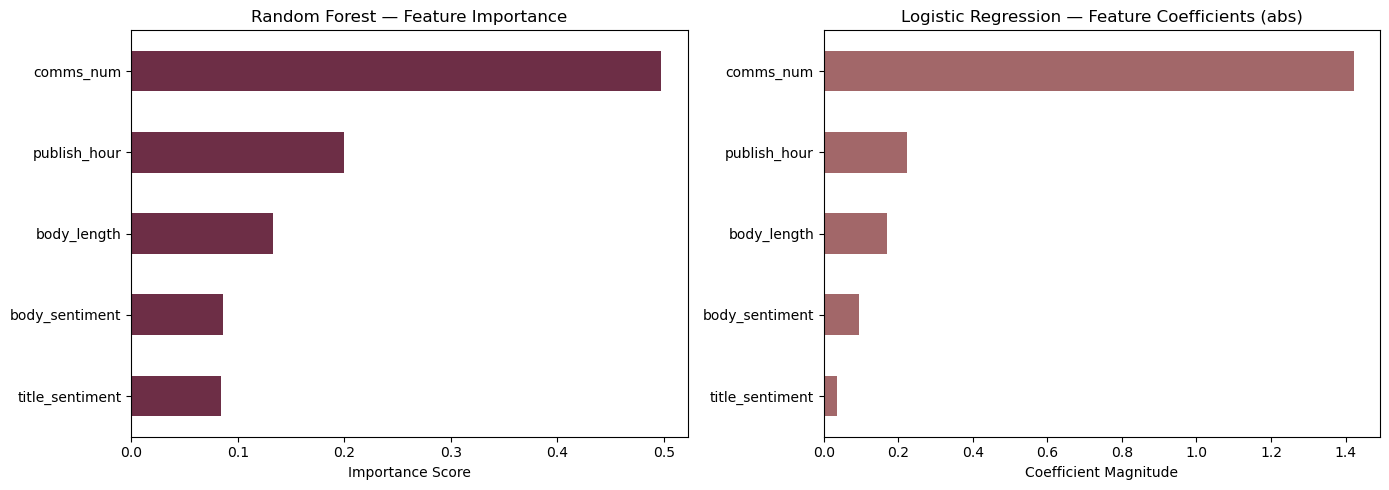

In [64]:
# Step 11: Feature Importance (Random Forest)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest feature importance
rf_importance = pd.Series(
    models['Random Forest'].feature_importances_, index=features
).sort_values(ascending=True)

rf_importance.plot(kind='barh', ax=axes[0], color='#6D2E46')
axes[0].set_title('Random Forest — Feature Importance')
axes[0].set_xlabel('Importance Score')

# Logistic Regression coefficients
lr_coefs = pd.Series(
    abs(models['Logistic Regression'].coef_[0]), index=features
).sort_values(ascending=True)

lr_coefs.plot(kind='barh', ax=axes[1], color='#A26769')
axes[1].set_title('Logistic Regression — Feature Coefficients (abs)')
axes[1].set_xlabel('Coefficient Magnitude')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

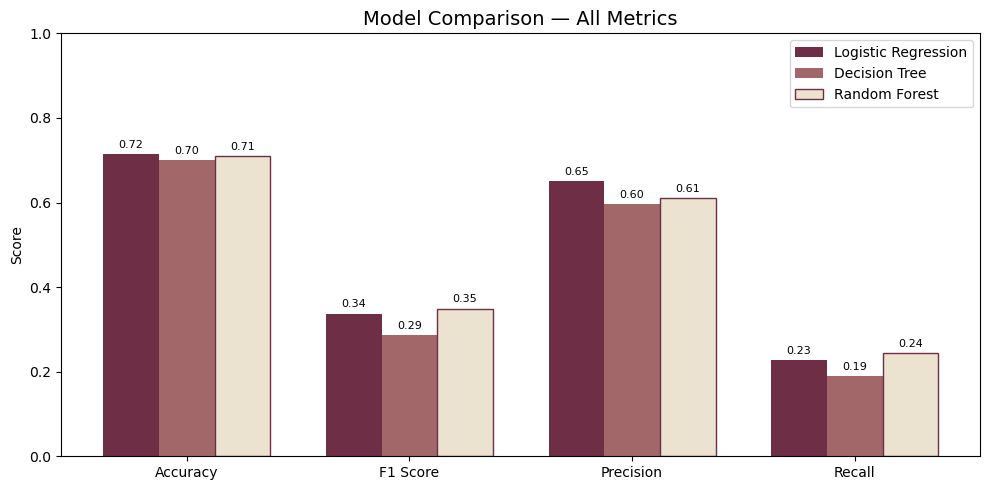

In [65]:
# Step 12: Model Comparison Summary Chart

metrics = ['Accuracy', 'F1 Score', 'Precision', 'Recall']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(x - width, results_df.loc['Logistic Regression', metrics], 
               width, label='Logistic Regression', color='#6D2E46')
bars2 = ax.bar(x, results_df.loc['Decision Tree', metrics], 
               width, label='Decision Tree', color='#A26769')
bars3 = ax.bar(x + width, results_df.loc['Random Forest', metrics], 
               width, label='Random Forest', color='#ECE2D0', edgecolor='#6D2E46')

ax.set_title('Model Comparison — All Metrics', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend()
ax.bar_label(bars1, fmt='%.2f', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='%.2f', padding=3, fontsize=8)
ax.bar_label(bars3, fmt='%.2f', padding=3, fontsize=8)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

In [66]:
# Step 13 (final): Topic Clustering with LDA — filtered corpus

from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import LatentDirichletAllocation

# Filter out bot/moderation posts before vectorizing
mask = ~df['body_clean'].str.contains(
    'subreddit|moderator|automod|removed|locked|bot|composeto|legal|necessarily',
    case=False, na=False
)
df_clean_lda = df[mask].copy()
print(f"Posts after filtering: {len(df_clean_lda)} (removed {len(df) - len(df_clean_lda)})")

custom_stopwords = [
    'throwra', 'reddit', 'post', 'account', 'create', 'new', 'action',
    'contact', 'users', 'rules', 'removed', 'limited', 'referring',
    'sexual', 'list', 'involving', 'comment', 'advice', 'questions',
    'just', 'like', 'dont', 'really', 'want', 'know', 'feel', 'im',
    'got', 'said', 'told', 'didnt', 'went', 'also', 'would', 'could',
    'get', 'go', 'one', 'think', 'time', 'way', 'thing', 'things',
    'youre', 'ive', 'thats', 'doesnt', 'wasnt', 'cant', 'hes', 'shes',
    'result', 'andor', 'ban', 'minors', 'allinclusive', 'rule',
    'appears', 'does', 'people', 'did', 'make', 'right', 'try',
    'trying', 'help', 'work', 'job', 'men', 'women', 'looks',
    'concerns', 'message', 'judgment', 'automatically', 'starts',
    'performed', 'bot', 'problems', 'subject', 'posts', 'permanent',
    'medical', 'welcome', 'locked', 'subreddit', 'letters', 'partners',
    'include', 'pass', 'number', 'joke', 'read', 'mean', 'say',
    'going', 'asked', 'started', 'talking', 'night', 'home', 'day'
]

all_stopwords = list(ENGLISH_STOP_WORDS) + custom_stopwords

vectorizer = CountVectorizer(
    max_df=0.90, min_df=10,
    max_features=1000,
    stop_words=all_stopwords
)
dtm = vectorizer.fit_transform(df_clean_lda['body_clean'])

lda = LatentDirichletAllocation(n_components=5, random_state=42, max_iter=20)
lda.fit(dtm)

words = vectorizer.get_feature_names_out()
print("\n=== TOP WORDS PER TOPIC ===\n")
for i, topic in enumerate(lda.components_):
    top_words = [words[j] for j in topic.argsort()[-10:][::-1]]
    print(f"Topic {i+1}: {', '.join(top_words)}")

Posts after filtering: 2000 (removed 825)

=== TOP WORDS PER TOPIC ===

Topic 1: love, relationship, life, felt, broke, months, wanted, ex, better, thought
Topic 2: life, years, relationship, need, good, family, money, child, leave, care
Topic 3: friends, friend, family, talk, house, year, christmas, bad, bf, come
Topic 4: relationship, sex, boyfriend, love, says, having, partner, makes, wants, stop
Topic 5: girl, months, ex, guy, dating, ago, relationship, talk, friends, date


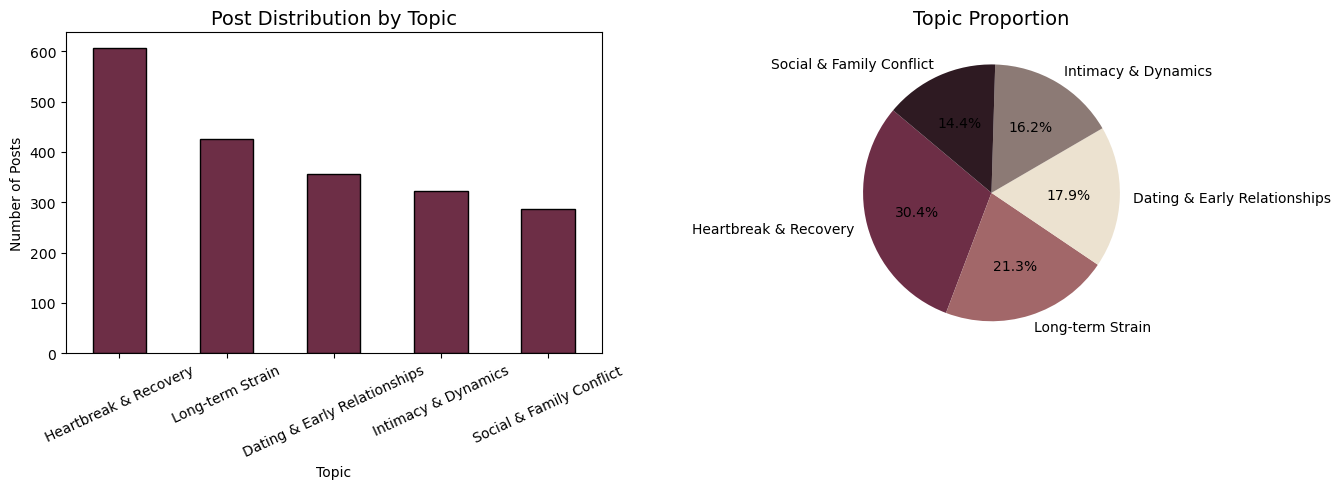

topic_label
Heartbreak & Recovery           607
Long-term Strain                426
Dating & Early Relationships    357
Intimacy & Dynamics             323
Social & Family Conflict        287
Name: count, dtype: int64


In [67]:
# Step 14: Assign Topic Labels & Visualize

# Assign dominant topic to each filtered post
topic_labels = {
    0: 'Heartbreak & Recovery',
    1: 'Long-term Strain',
    2: 'Social & Family Conflict',
    3: 'Intimacy & Dynamics',
    4: 'Dating & Early Relationships'
}

# Get topic distribution for filtered posts
topic_assignments = lda.transform(dtm)
df_clean_lda['dominant_topic'] = topic_assignments.argmax(axis=1)
df_clean_lda['topic_label'] = df_clean_lda['dominant_topic'].map(topic_labels)

# Plot topic distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
topic_counts = df_clean_lda['topic_label'].value_counts()
topic_counts.plot(kind='bar', ax=axes[0], color='#6D2E46', edgecolor='black')
axes[0].set_title('Post Distribution by Topic', fontsize=14)
axes[0].set_xlabel('Topic')
axes[0].set_ylabel('Number of Posts')
axes[0].tick_params(axis='x', rotation=25)

# Pie chart
axes[1].pie(topic_counts.values, labels=topic_counts.index,
            autopct='%1.1f%%', startangle=140,
            colors=['#6D2E46','#A26769','#ECE2D0','#8C7A75','#2E1A22'])
axes[1].set_title('Topic Proportion', fontsize=14)

plt.tight_layout()
plt.savefig('topic_distribution.png', dpi=150)
plt.show()

print(df_clean_lda['topic_label'].value_counts())

In [68]:
# Step 15: Improved Models with Class Weighting

from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.metrics import precision_score, recall_score

print("=" * 50)
print("IMPROVED MODELS — class_weight='balanced'")
print("=" * 50)

improved_models = {
    'Logistic Regression (Balanced)': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'
    ),
    'Decision Tree (Balanced)': DecisionTreeClassifier(
        max_depth=5, random_state=42, class_weight='balanced'
    ),
    'Random Forest (Balanced)': RandomForestClassifier(
        n_estimators=100, max_depth=5, random_state=42, class_weight='balanced'
    )
}

improved_results = {}

for name, model in improved_models.items():
    if 'Logistic' in name:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    improved_results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred)
    }

    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(classification_report(y_test, y_pred))

improved_df = pd.DataFrame(improved_results).T
print("\n--- Improved Model Comparison ---")
print(improved_df.round(3))

IMPROVED MODELS — class_weight='balanced'

  Logistic Regression (Balanced)
              precision    recall  f1-score   support

           0       0.80      0.75      0.77       385
           1       0.52      0.60      0.56       180

    accuracy                           0.70       565
   macro avg       0.66      0.67      0.67       565
weighted avg       0.71      0.70      0.70       565


  Decision Tree (Balanced)
              precision    recall  f1-score   support

           0       0.95      0.51      0.66       385
           1       0.47      0.94      0.63       180

    accuracy                           0.65       565
   macro avg       0.71      0.73      0.65       565
weighted avg       0.80      0.65      0.65       565


  Random Forest (Balanced)
              precision    recall  f1-score   support

           0       0.89      0.57      0.69       385
           1       0.48      0.86      0.61       180

    accuracy                           0.66       

In [69]:
pip install -U imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [70]:
# Step 16: SMOTE + Improved Random Forest

from imblearn.over_sampling import SMOTE

# Check if imbalanced-learn is installed
try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'imbalanced-learn', '--break-system-packages'])
    from imblearn.over_sampling import SMOTE

# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Original training shape: {X_train.shape}")
print(f"After SMOTE: {X_train_smote.shape}")
print(f"Class distribution after SMOTE:\n{pd.Series(y_train_smote).value_counts()}")

# Train all three on SMOTE data
print("\n" + "="*50)
print("SMOTE MODELS")
print("="*50)

smote_models = {
    'Logistic Regression (SMOTE)': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree (SMOTE)': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest (SMOTE)': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
}

smote_results = {}

for name, model in smote_models.items():
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test_scaled)

    smote_results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred)
    }

    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(classification_report(y_test, y_pred))

smote_df = pd.DataFrame(smote_results).T
print("\n--- SMOTE Model Comparison ---")
print(smote_df.round(3))

Original training shape: (2260, 5)
After SMOTE: (3084, 5)
Class distribution after SMOTE:
high_engagement
0    1542
1    1542
Name: count, dtype: int64

SMOTE MODELS

  Logistic Regression (SMOTE)
              precision    recall  f1-score   support

           0       0.81      0.75      0.78       385
           1       0.54      0.63      0.58       180

    accuracy                           0.71       565
   macro avg       0.68      0.69      0.68       565
weighted avg       0.73      0.71      0.72       565


  Decision Tree (SMOTE)
              precision    recall  f1-score   support

           0       0.90      0.60      0.72       385
           1       0.50      0.86      0.63       180

    accuracy                           0.68       565
   macro avg       0.70      0.73      0.68       565
weighted avg       0.77      0.68      0.69       565


  Random Forest (SMOTE)
              precision    recall  f1-score   support

           0       0.88      0.58      0.70 

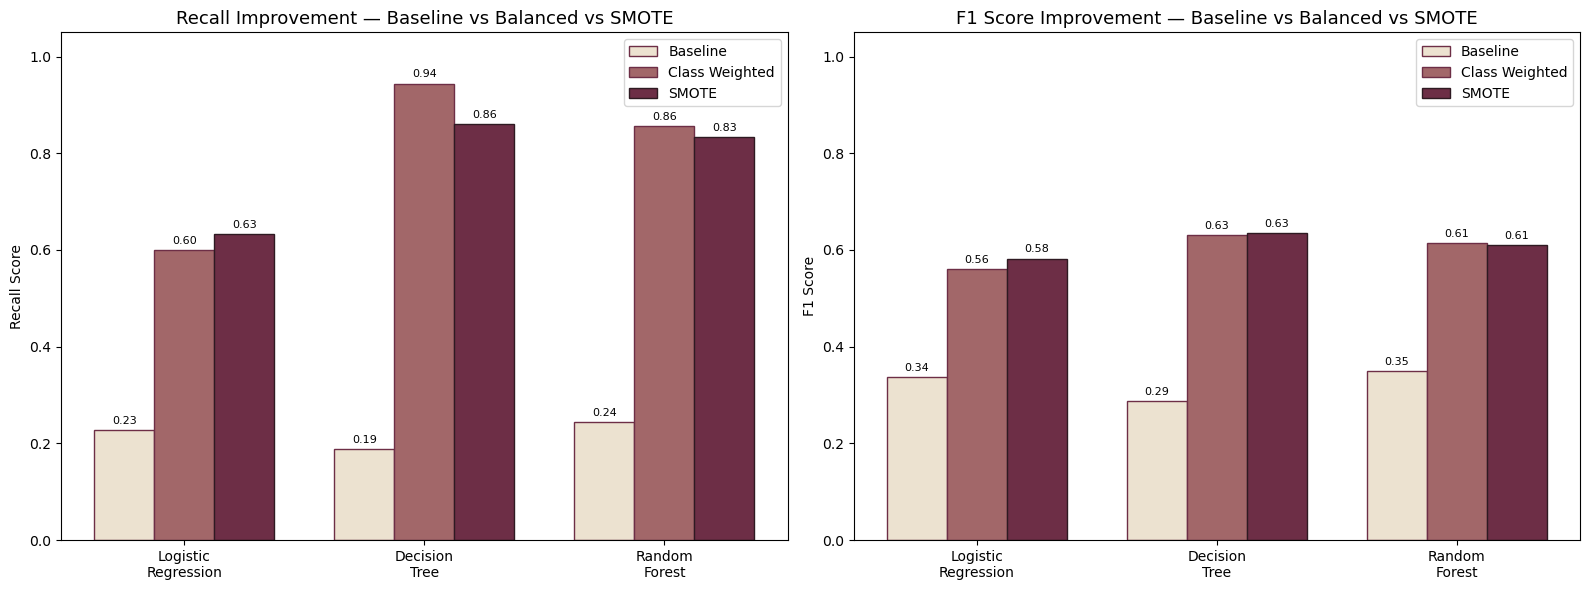

In [71]:
# Step 17: Before vs After Comparison Chart

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Recall comparison across all versions
models_names = ['Logistic\nRegression', 'Decision\nTree', 'Random\nForest']
baseline_recall = [0.228, 0.189, 0.244]
balanced_recall = [0.600, 0.944, 0.856]
smote_recall = [0.633, 0.861, 0.833]

x = np.arange(len(models_names))
width = 0.25

axes[0].bar(x - width, baseline_recall, width, label='Baseline', color='#ECE2D0', edgecolor='#6D2E46')
axes[0].bar(x, balanced_recall, width, label='Class Weighted', color='#A26769', edgecolor='#6D2E46')
axes[0].bar(x + width, smote_recall, width, label='SMOTE', color='#6D2E46', edgecolor='#2E1A22')
axes[0].set_title('Recall Improvement — Baseline vs Balanced vs SMOTE', fontsize=13)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_names)
axes[0].set_ylabel('Recall Score')
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].bar_label(axes[0].containers[0], fmt='%.2f', padding=3, fontsize=8)
axes[0].bar_label(axes[0].containers[1], fmt='%.2f', padding=3, fontsize=8)
axes[0].bar_label(axes[0].containers[2], fmt='%.2f', padding=3, fontsize=8)

# F1 comparison
baseline_f1 = [0.337, 0.287, 0.349]
balanced_f1 = [0.560, 0.630, 0.615]
smote_f1 = [0.582, 0.634, 0.610]

axes[1].bar(x - width, baseline_f1, width, label='Baseline', color='#ECE2D0', edgecolor='#6D2E46')
axes[1].bar(x, balanced_f1, width, label='Class Weighted', color='#A26769', edgecolor='#6D2E46')
axes[1].bar(x + width, smote_f1, width, label='SMOTE', color='#6D2E46', edgecolor='#2E1A22')
axes[1].set_title('F1 Score Improvement — Baseline vs Balanced vs SMOTE', fontsize=13)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models_names)
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].bar_label(axes[1].containers[0], fmt='%.2f', padding=3, fontsize=8)
axes[1].bar_label(axes[1].containers[1], fmt='%.2f', padding=3, fontsize=8)
axes[1].bar_label(axes[1].containers[2], fmt='%.2f', padding=3, fontsize=8)

plt.tight_layout()
plt.savefig('improvement_comparison.png', dpi=150)
plt.show()

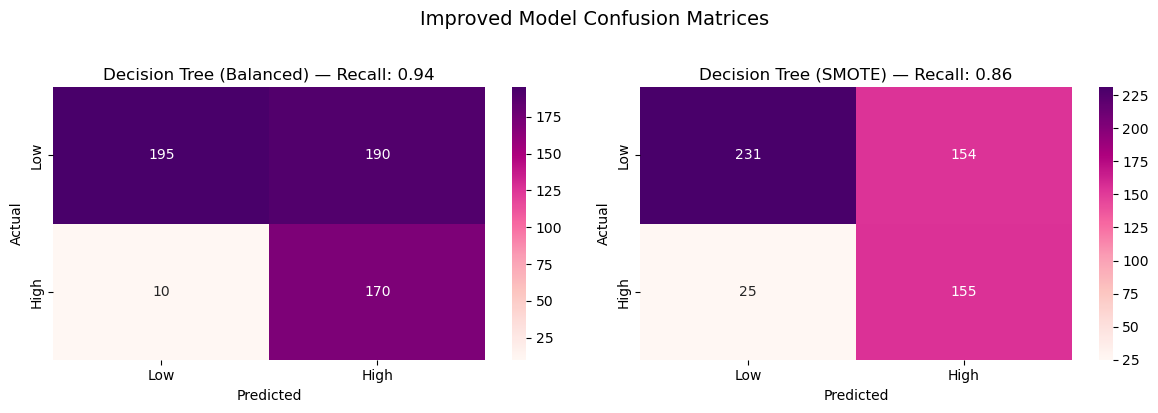

In [72]:
# Confusion matrices for best improved models
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Best balanced model — Decision Tree (highest recall 0.94)
y_pred_dt_bal = improved_models['Decision Tree (Balanced)'].predict(X_test)
cm_dt = confusion_matrix(y_test, y_pred_dt_bal)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='RdPu', ax=axes[0],
            xticklabels=['Low','High'], yticklabels=['Low','High'])
axes[0].set_title('Decision Tree (Balanced) — Recall: 0.94')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Best SMOTE model — Decision Tree SMOTE (recall 0.86)
y_pred_dt_smote = smote_models['Decision Tree (SMOTE)'].predict(X_test_scaled)
cm_smote = confusion_matrix(y_test, y_pred_dt_smote)
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='RdPu', ax=axes[1],
            xticklabels=['Low','High'], yticklabels=['Low','High'])
axes[1].set_title('Decision Tree (SMOTE) — Recall: 0.86')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle('Improved Model Confusion Matrices', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices_improved.png', dpi=150)
plt.show()

In [73]:
# Export processed dataset
df.to_csv(r"C:\Users\Ahone\Desktop\Data analytics project\datasets\processed\reddit_processed.csv", index=False)
print("Exported successfully:", df.shape)

Exported successfully: (2825, 14)
